In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/Users/vivekarya/Documents/GitHub/bess_trading_assessment")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

price_df = pd.read_csv(PROCESSED_DIR / "price_clean.csv")
demand_df = pd.read_csv(PROCESSED_DIR / "demand_clean.csv")
pv_df = pd.read_csv(PROCESSED_DIR / "pv_clean.csv")

print(price_df.shape, demand_df.shape, pv_df.shape)


(2065, 3) (384, 3) (377, 3)


## Step 3.1 — Convert the datetime columns 

In [2]:
price_df["SETTLEMENTDATE"] = pd.to_datetime(price_df["SETTLEMENTDATE"])
demand_df["SETTLEMENTDATE"] = pd.to_datetime(demand_df["SETTLEMENTDATE"])
pv_df["SETTLEMENTDATE"] = pd.to_datetime(pv_df["SETTLEMENTDATE"])

## Step 3.2 — Check date ranges

In [3]:
print("Price:", price_df["SETTLEMENTDATE"].min(), "to", price_df["SETTLEMENTDATE"].max())
print("Demand:", demand_df["SETTLEMENTDATE"].min(), "to", demand_df["SETTLEMENTDATE"].max())
print("PV:", pv_df["SETTLEMENTDATE"].min(), "to", pv_df["SETTLEMENTDATE"].max())

Price: 2026-03-09 00:00:00 to 2026-03-16 04:00:00
Demand: 2026-03-09 00:00:00 to 2026-03-16 23:30:00
PV: 2026-03-09 00:00:00 to 2026-03-16 23:30:00


## Step 3.3 — Check columns 

In [4]:
print(price_df.columns)
print(demand_df.columns)
print(pv_df.columns)

Index(['SETTLEMENTDATE', 'REGIONID', 'RRP'], dtype='object')
Index(['SETTLEMENTDATE', 'REGIONID', 'TOTALDEMAND'], dtype='object')
Index(['SETTLEMENTDATE', 'REGIONID', 'PV_MW'], dtype='object')


## converting price from 5-minute to 30-minute 

In [5]:
price_30_df = (
    price_df
    .set_index("SETTLEMENTDATE")
    .groupby("REGIONID")["RRP"]
    .resample("30min")
    .mean()
    .reset_index()
)

In [6]:
print(price_30_df.shape)
print(price_30_df.head())
print(price_30_df.tail())

(345, 3)
  REGIONID      SETTLEMENTDATE        RRP
0     VIC1 2026-03-09 00:00:00  61.873592
1     VIC1 2026-03-09 00:30:00  60.998663
2     VIC1 2026-03-09 01:00:00  65.790635
3     VIC1 2026-03-09 01:30:00  67.643523
4     VIC1 2026-03-09 02:00:00  63.400825
    REGIONID      SETTLEMENTDATE        RRP
340     VIC1 2026-03-16 02:00:00  60.327218
341     VIC1 2026-03-16 02:30:00  58.578307
342     VIC1 2026-03-16 03:00:00  57.634825
343     VIC1 2026-03-16 03:30:00  60.076228
344     VIC1 2026-03-16 04:00:00  65.490510


In [7]:
print(price_30_df["SETTLEMENTDATE"].min(), price_30_df["SETTLEMENTDATE"].max())
print(price_30_df["REGIONID"].unique())

2026-03-09 00:00:00 2026-03-16 04:00:00
['VIC1']


## Step 5.1 — First filter everything to VIC1

In [8]:
price_30_df = price_30_df[price_30_df["REGIONID"] == "VIC1"].copy()
demand_df = demand_df[demand_df["REGIONID"] == "VIC1"].copy()
pv_df = pv_df[pv_df["REGIONID"] == "VIC1"].copy()

## Step 5.2 — Merging price + demand

In [9]:
merged_df = pd.merge(
    price_30_df,
    demand_df,
    on=["SETTLEMENTDATE", "REGIONID"],
    how="inner"
)

print("After merging price + demand:", merged_df.shape)

After merging price + demand: (345, 4)


## Step 5.3 — Merging PV

In [10]:
merged_df = pd.merge(
    merged_df,
    pv_df,
    on=["SETTLEMENTDATE", "REGIONID"],
    how="inner"
)

print("Final merged shape:", merged_df.shape)

Final merged shape: (338, 5)


In [11]:
print(merged_df.head())
print(merged_df.tail())

print("Missing values:\n", merged_df.isna().sum())

  REGIONID      SETTLEMENTDATE        RRP  TOTALDEMAND  PV_MW
0     VIC1 2026-03-09 00:00:00  61.873592         4681    0.0
1     VIC1 2026-03-09 00:30:00  60.998663         4490    0.0
2     VIC1 2026-03-09 01:00:00  65.790635         4392    0.0
3     VIC1 2026-03-09 01:30:00  67.643523         4302    0.0
4     VIC1 2026-03-09 02:00:00  63.400825         4211    0.0
    REGIONID      SETTLEMENTDATE        RRP  TOTALDEMAND  PV_MW
333     VIC1 2026-03-16 02:00:00  60.327218         4400    0.0
334     VIC1 2026-03-16 02:30:00  58.578307         4317    0.0
335     VIC1 2026-03-16 03:00:00  57.634825         4316    0.0
336     VIC1 2026-03-16 03:30:00  60.076228         4306    0.0
337     VIC1 2026-03-16 04:00:00  65.490510         4337    0.0
Missing values:
 REGIONID          0
SETTLEMENTDATE    0
RRP               0
TOTALDEMAND       0
PV_MW             0
dtype: int64


## FEATURE ENGINEERING

### Step 6.1 — Create NET DEMAND

In [12]:
merged_df["NET_DEMAND"] = merged_df["TOTALDEMAND"] - merged_df["PV_MW"]

### Step 6.2 — Adding useful time features

In [13]:
merged_df["DATE"] = merged_df["SETTLEMENTDATE"].dt.date
merged_df["HOUR"] = merged_df["SETTLEMENTDATE"].dt.hour
merged_df["MINUTE"] = merged_df["SETTLEMENTDATE"].dt.minute

In [14]:
merged_df

,REGIONID,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND,DATE,HOUR,MINUTE
0,VIC1,2026-03-09 00:00:00,61.873592,4681,0.0,4681.0,2026-03-09,0,0
1,VIC1,2026-03-09 00:30:00,60.998663,4490,0.0,4490.0,2026-03-09,0,30
2,VIC1,2026-03-09 01:00:00,65.790635,4392,0.0,4392.0,2026-03-09,1,0
3,VIC1,2026-03-09 01:30:00,67.643523,4302,0.0,4302.0,2026-03-09,1,30
4,VIC1,2026-03-09 02:00:00,63.400825,4211,0.0,4211.0,2026-03-09,2,0
...,...,...,...,...,...,...,...,...,...
333,VIC1,2026-03-16 02:00:00,60.327218,4400,0.0,4400.0,2026-03-16,2,0
334,VIC1,2026-03-16 02:30:00,58.578307,4317,0.0,4317.0,2026-03-16,2,30
335,VIC1,2026-03-16 03:00:00,57.634825,4316,0.0,4316.0,2026-03-16,3,0
336,VIC1,2026-03-16 03:30:00,60.076228,4306,0.0,4306.0,2026-03-16,3,30


In [15]:
print(merged_df.head())

  REGIONID      SETTLEMENTDATE        RRP  TOTALDEMAND  PV_MW  NET_DEMAND  \
0     VIC1 2026-03-09 00:00:00  61.873592         4681    0.0      4681.0   
1     VIC1 2026-03-09 00:30:00  60.998663         4490    0.0      4490.0   
2     VIC1 2026-03-09 01:00:00  65.790635         4392    0.0      4392.0   
3     VIC1 2026-03-09 01:30:00  67.643523         4302    0.0      4302.0   
4     VIC1 2026-03-09 02:00:00  63.400825         4211    0.0      4211.0   

         DATE  HOUR  MINUTE  
0  2026-03-09     0       0  
1  2026-03-09     0      30  
2  2026-03-09     1       0  
3  2026-03-09     1      30  
4  2026-03-09     2       0  


In [16]:
print(merged_df.tail())

    REGIONID      SETTLEMENTDATE        RRP  TOTALDEMAND  PV_MW  NET_DEMAND  \
333     VIC1 2026-03-16 02:00:00  60.327218         4400    0.0      4400.0   
334     VIC1 2026-03-16 02:30:00  58.578307         4317    0.0      4317.0   
335     VIC1 2026-03-16 03:00:00  57.634825         4316    0.0      4316.0   
336     VIC1 2026-03-16 03:30:00  60.076228         4306    0.0      4306.0   
337     VIC1 2026-03-16 04:00:00  65.490510         4337    0.0      4337.0   

           DATE  HOUR  MINUTE  
333  2026-03-16     2       0  
334  2026-03-16     2      30  
335  2026-03-16     3       0  
336  2026-03-16     3      30  
337  2026-03-16     4       0  


In [17]:
# Count of non-zero values
count = (merged_df['PV_MW'] != 0).sum()
print(f"Total non-zero intervals: {count}")

# Get the basic stats for non-zero periods only
print(merged_df[merged_df['PV_MW'] > 0]['PV_MW'].describe())

Total non-zero intervals: 176
count     176.000000
mean     1681.563398
std      1196.141627
min         0.929000
25%       667.760250
50%      1535.224000
75%      2791.156750
max      3881.165000
Name: PV_MW, dtype: float64


## Step 6.3 → EDA 

In [18]:
merged_df.describe()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   REGIONID        338 non-null    object        
 1   SETTLEMENTDATE  338 non-null    datetime64[ns]
 2   RRP             338 non-null    float64       
 3   TOTALDEMAND     338 non-null    int64         
 4   PV_MW           338 non-null    float64       
 5   NET_DEMAND      338 non-null    float64       
 6   DATE            338 non-null    object        
 7   HOUR            338 non-null    int32         
 8   MINUTE          338 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(2)
memory usage: 21.3+ KB


### 6.3.1 Time-based patterns

In [19]:
merged_df.groupby("HOUR")[["RRP","TOTALDEMAND","PV_MW","NET_DEMAND"]].mean()

,RRP,TOTALDEMAND,PV_MW,NET_DEMAND
HOUR,,,,
0,35.066235,4753.500000,0.000000,4753.500000
1,31.975195,4502.375000,0.000000,4502.375000
2,30.349470,4326.562500,0.000000,4326.562500
3,32.212631,4267.250000,0.000000,4267.250000
4,35.812416,4325.866667,0.000000,4325.866667
5,37.255169,4578.857143,0.000000,4578.857143
6,39.346619,5051.214286,23.667571,5027.546714
7,7.562271,5206.642857,417.844786,4788.798071
8,-6.313550,4858.785714,1120.161143,3738.624571


### Price Behaviour (Negative + Peak Prices)

In [20]:
# Basic stats
print(merged_df["RRP"].describe())

# Negative prices
negative_prices = merged_df[merged_df["RRP"] < 0]
print("Total negative intervals:", len(negative_prices))

# Peak prices (top 5)
peak_prices = merged_df.sort_values("RRP", ascending=False).head(5)
print(peak_prices[["SETTLEMENTDATE", "RRP"]])

count    338.000000
mean      19.325074
std       36.789976
min      -44.818333
25%       -6.256995
50%        8.512980
75%       50.765167
max      115.946070
Name: RRP, dtype: float64
Total negative intervals: 141
         SETTLEMENTDATE         RRP
60  2026-03-10 06:00:00  115.946070
61  2026-03-10 06:30:00  107.351280
322 2026-03-15 20:30:00  106.890837
321 2026-03-15 20:00:00  102.956303
59  2026-03-10 05:30:00   98.991522


## step 6.3.2 PV vs Price Relationship

            RRP     PV_MW
RRP    1.000000 -0.531824
PV_MW -0.531824  1.000000


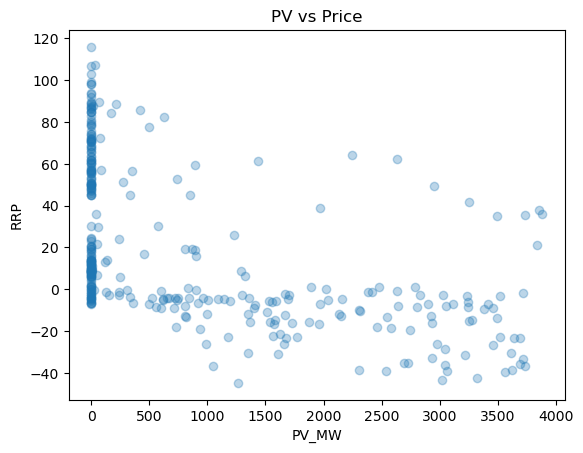

In [21]:
# Correlation
corr = merged_df[["RRP", "PV_MW"]].corr()
print(corr)


import matplotlib.pyplot as plt

plt.scatter(merged_df["PV_MW"], merged_df["RRP"], alpha=0.3)
plt.xlabel("PV_MW")
plt.ylabel("RRP")
plt.title("PV vs Price")
plt.show()

### Step 6.3.5. Net Demand Insight

In [22]:
# Correlation with net demand
corr_net = merged_df[["RRP", "NET_DEMAND"]].corr()
print(corr_net)

                 RRP  NET_DEMAND
RRP         1.000000    0.506218
NET_DEMAND  0.506218    1.000000


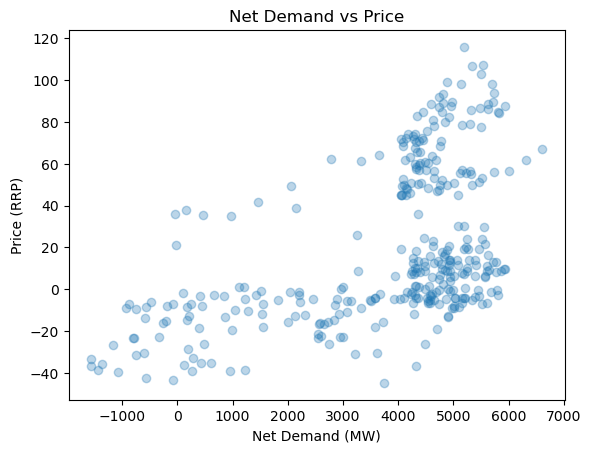

In [23]:
plt.figure()
plt.scatter(merged_df["NET_DEMAND"], merged_df["RRP"], alpha=0.3)
plt.xlabel("Net Demand (MW)")
plt.ylabel("Price (RRP)")
plt.title("Net Demand vs Price")
plt.show()

## 6.3.6 Negative price analaysis

In [24]:
# Extract negative price intervals
neg_df = merged_df[merged_df["RRP"] < 0]

print(neg_df[["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND"]].head())

# Count by hour
neg_by_hour = neg_df.groupby("HOUR").size()
print(neg_by_hour)

        SETTLEMENTDATE        RRP  TOTALDEMAND     PV_MW  NET_DEMAND
15 2026-03-09 07:30:00 -18.249260         4303   729.339    3573.661
16 2026-03-09 08:00:00 -22.895882         4185  1181.132    3003.868
17 2026-03-09 08:30:00 -12.188032         3976  1666.704    2309.296
18 2026-03-09 09:00:00 -11.981667         3669  2134.493    1534.507
19 2026-03-09 09:30:00 -13.278333         3415  2548.374     866.626
HOUR
0      2
1      3
2      4
3      4
4      2
5      2
6      2
7      9
8     12
9     13
10    14
11    12
12    11
13    12
14    11
15    10
16    10
17     5
18     3
dtype: int64


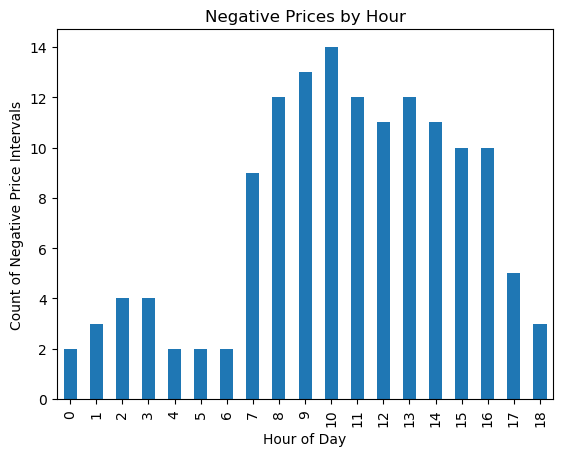

In [25]:
neg_df = merged_df[merged_df["RRP"] < 0]

neg_by_hour = neg_df.groupby("HOUR").size()

plt.figure()
neg_by_hour.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("Count of Negative Price Intervals")
plt.title("Negative Prices by Hour")
plt.show()

### 6.3.7. Daily Cycle

In [26]:
# Hourly average pattern
hourly_df = merged_df.groupby("HOUR")[["RRP","TOTALDEMAND","PV_MW","NET_DEMAND"]].mean()

print(hourly_df)

            RRP  TOTALDEMAND        PV_MW   NET_DEMAND
HOUR                                                  
0     35.066235  4753.500000     0.000000  4753.500000
1     31.975195  4502.375000     0.000000  4502.375000
2     30.349470  4326.562500     0.000000  4326.562500
3     32.212631  4267.250000     0.000000  4267.250000
4     35.812416  4325.866667     0.000000  4325.866667
5     37.255169  4578.857143     0.000000  4578.857143
6     39.346619  5051.214286    23.667571  5027.546714
7      7.562271  5206.642857   417.844786  4788.798071
8     -6.313550  4858.785714  1120.161143  3738.624571
9    -12.074272  4412.714286  1791.576429  2621.137857
10   -12.640134  4035.785714  2301.427286  1734.358429
11    -9.957979  3782.642857  2679.988571  1102.654286
12   -14.059013  3608.785714  2880.624214   728.161500
13   -13.014618  3636.714286  2811.126357   825.587929
14   -10.960208  3844.500000  2572.775929  1271.724071
15    -3.214858  4132.142857  2211.730571  1920.412286
16     8.9

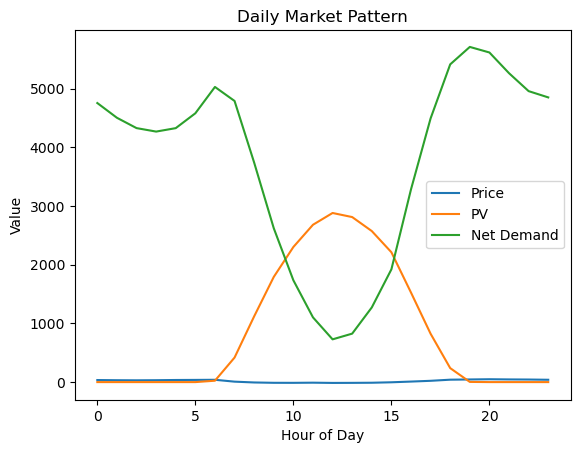

In [27]:
hourly_df = merged_df.groupby("HOUR")[["RRP","TOTALDEMAND","PV_MW","NET_DEMAND"]].mean()

plt.figure()
plt.plot(hourly_df.index, hourly_df["RRP"], label="Price")
plt.plot(hourly_df.index, hourly_df["PV_MW"], label="PV")
plt.plot(hourly_df.index, hourly_df["NET_DEMAND"], label="Net Demand")

plt.xlabel("Hour of Day")
plt.ylabel("Value")
plt.title("Daily Market Pattern")
plt.legend()
plt.show()

In [28]:
merged_df.to_csv("/Users/vivekarya/Documents/GitHub/bess_trading_assessment/data/processed/merged_dataset.csv", index=False)

## Spilitting data set for Exersises 1 and 2 

## D-1 dataset (16 March)

In [29]:
# D-1 dataset (16 March)
d1_df = merged_df[merged_df["DATE"] == "2026-03-16"]
d1_df.to_csv("/Users/vivekarya/Documents/GitHub/bess_trading_assessment/data/processed/exercise1_d1.csv", index=False)


## Weekly dataset (9–15 March)

In [30]:

# Weekly dataset (9–15 March)
weekly_df = merged_df[
    (merged_df["SETTLEMENTDATE"] >= "2026-03-09") &
    (merged_df["SETTLEMENTDATE"] < "2026-03-16")
]
weekly_df.to_csv("/Users/vivekarya/Documents/GitHub/bess_trading_assessment/data/processed/exercise2_weekly.csv", index=False)

In [31]:
d1_df.shape


(0, 9)

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# Donot Consider this more 

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

### Step 7.1 — Spliting the data 
--- Weekly (9–15 March)

In [32]:
weekly_df = merged_df[
    (merged_df["SETTLEMENTDATE"] >= "2026-03-09") &
    (merged_df["SETTLEMENTDATE"] < "2026-03-16")
].copy()

print("Weekly shape:", weekly_df.shape)

Weekly shape: (329, 9)


### Step 7.2 : D-1 (16 March)

In [33]:
d1_df = merged_df[
    (merged_df["SETTLEMENTDATE"] >= "2026-03-16") &
    (merged_df["SETTLEMENTDATE"] < "2026-03-17")
].copy()

print("D-1 shape:", d1_df.shape)

D-1 shape: (9, 9)


### Step 7.2 — Price behaviour (when high / low?)

In [34]:
print("Max price:", weekly_df["RRP"].max())
print("Min price:", weekly_df["RRP"].min())
print("Average price:", weekly_df["RRP"].mean())

Max price: 115.94607
Min price: -44.81833333333333
Average price: 18.17728073454914


### High price intervals 

In [35]:
weekly_df.sort_values("RRP", ascending=False)[
    ["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW"]
].head(10)

,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW
60,2026-03-10 06:00:00,115.946070,5198,0.000
61,2026-03-10 06:30:00,107.351280,5570,36.743
322,2026-03-15 20:30:00,106.890837,5335,0.000
321,2026-03-15 20:00:00,102.956303,5500,0.000
59,2026-03-10 05:30:00,98.991522,4882,0.000
320,2026-03-15 19:30:00,98.156298,5693,0.000
323,2026-03-15 21:00:00,98.030000,5146,0.000
319,2026-03-15 19:00:00,94.100475,5735,0.929
47,2026-03-09 23:30:00,93.286680,4810,0.000
46,2026-03-09 23:00:00,92.012368,4734,0.000


### Lowest price intervals

In [36]:
weekly_df.sort_values("RRP")[
    ["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW"]
].head(10)

,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW
119,2026-03-11 15:00:00,-44.818333,5010,1262.737
254,2026-03-14 10:30:00,-43.191667,2928,3017.164
255,2026-03-14 11:00:00,-42.671667,2753,3322.119
256,2026-03-14 11:30:00,-39.611892,2480,3562.405
210,2026-03-13 12:30:00,-39.258333,3325,3062.583
215,2026-03-13 15:00:00,-38.918367,3483,2537.526
252,2026-03-14 09:30:00,-38.749668,3525,2302.116
260,2026-03-14 13:30:00,-38.616565,2185,3622.568
258,2026-03-14 12:30:00,-36.853333,2169,3732.187
118,2026-03-11 14:30:00,-36.516667,5363,1048.731


## 🔋 BESS Charging Opportunity Analysis (Negative Price Events)

The analysis of the most negative price intervals reveals a clear solar-driven oversupply pattern within the NEM. These events primarily occur during late morning to midday periods, where rooftop PV generation is at its peak.

During these intervals, PV generation ranges from approximately 1,000 MW to over 3,700 MW, while demand remains relatively low to moderate. This results in significantly reduced net demand, and in some cases, effective oversupply conditions where solar generation dominates system requirements. As a result, prices fall into deeply negative territory, reaching levels as low as -$44/MWh.

These negative price events represent optimal charging opportunities for Battery Energy Storage Systems (BESS), as operators are effectively incentivised to absorb excess generation while being financially compensated.

The occurrence of such events across multiple days (e.g., 11th, 13th, and 14th March) indicates recurring solar-driven market behaviour, although the magnitude and timing vary depending on demand and renewable output.

When combined with higher evening prices driven by increased demand and reduced solar generation, these negative price intervals create strong arbitrage opportunities. This supports a BESS strategy focused on charging during midday solar peaks and discharging during evening demand peaks.

---

### 🔑 Key Insight
Negative prices are primarily driven by high solar generation and low net demand, creating highly favourable charging conditions for BESS.

## Step 3 — PV impact

In [37]:
hourly = weekly_df.groupby("HOUR").agg({
    "RRP": "mean",
    "TOTALDEMAND": "mean",
    "PV_MW": "mean",
    "NET_DEMAND": "mean"
}).reset_index()

print(hourly)

    HOUR        RRP  TOTALDEMAND        PV_MW   NET_DEMAND
0      0  30.633951  4762.500000     0.000000  4762.500000
1      1  28.167502  4499.714286     0.000000  4499.714286
2      2  26.191857  4322.000000     0.000000  4322.000000
3      3  28.406502  4261.000000     0.000000  4261.000000
4      4  33.692552  4325.071429     0.000000  4325.071429
5      5  37.255169  4578.857143     0.000000  4578.857143
6      6  39.346619  5051.214286    23.667571  5027.546714
7      7   7.562271  5206.642857   417.844786  4788.798071
8      8  -6.313550  4858.785714  1120.161143  3738.624571
9      9 -12.074272  4412.714286  1791.576429  2621.137857
10    10 -12.640134  4035.785714  2301.427286  1734.358429
11    11  -9.957979  3782.642857  2679.988571  1102.654286
12    12 -14.059013  3608.785714  2880.624214   728.161500
13    13 -13.014618  3636.714286  2811.126357   825.587929
14    14 -10.960208  3844.500000  2572.775929  1271.724071
15    15  -3.214858  4132.142857  2211.730571  1920.4122

### D-1 ANALYSIS

### Step 8.1 — Look at D-1 day

In [38]:
d1_df.sort_values("SETTLEMENTDATE").head(20)

,REGIONID,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND,DATE,HOUR,MINUTE
329,VIC1,2026-03-16 00:00:00,68.530705,4764,0.0,4764.0,2026-03-16,0,0
330,VIC1,2026-03-16 00:30:00,63.653745,4617,0.0,4617.0,2026-03-16,0,30
331,VIC1,2026-03-16 01:00:00,60.242388,4542,0.0,4542.0,2026-03-16,1,0
332,VIC1,2026-03-16 01:30:00,57.015702,4500,0.0,4500.0,2026-03-16,1,30
333,VIC1,2026-03-16 02:00:00,60.327218,4400,0.0,4400.0,2026-03-16,2,0
334,VIC1,2026-03-16 02:30:00,58.578307,4317,0.0,4317.0,2026-03-16,2,30
335,VIC1,2026-03-16 03:00:00,57.634825,4316,0.0,4316.0,2026-03-16,3,0
336,VIC1,2026-03-16 03:30:00,60.076228,4306,0.0,4306.0,2026-03-16,3,30
337,VIC1,2026-03-16 04:00:00,65.490510,4337,0.0,4337.0,2026-03-16,4,0


## Step 8.2 — Finding  LOW price for charging cycle

In [39]:
d1_df.sort_values("RRP")[
    ["SETTLEMENTDATE", "RRP", "PV_MW", "TOTALDEMAND"]
].head(10)


,SETTLEMENTDATE,RRP,PV_MW,TOTALDEMAND
332,2026-03-16 01:30:00,57.015702,0.0,4500
335,2026-03-16 03:00:00,57.634825,0.0,4316
334,2026-03-16 02:30:00,58.578307,0.0,4317
336,2026-03-16 03:30:00,60.076228,0.0,4306
331,2026-03-16 01:00:00,60.242388,0.0,4542
333,2026-03-16 02:00:00,60.327218,0.0,4400
330,2026-03-16 00:30:00,63.653745,0.0,4617
337,2026-03-16 04:00:00,65.490510,0.0,4337
329,2026-03-16 00:00:00,68.530705,0.0,4764


#### Step 8.3 — Find HIGH price (discharge time)

In [40]:
d1_df.sort_values("RRP", ascending=False)[
    ["SETTLEMENTDATE", "RRP", "PV_MW", "TOTALDEMAND"]
].head(10)

,SETTLEMENTDATE,RRP,PV_MW,TOTALDEMAND
329,2026-03-16 00:00:00,68.530705,0.0,4764
337,2026-03-16 04:00:00,65.490510,0.0,4337
330,2026-03-16 00:30:00,63.653745,0.0,4617
333,2026-03-16 02:00:00,60.327218,0.0,4400
331,2026-03-16 01:00:00,60.242388,0.0,4542
336,2026-03-16 03:30:00,60.076228,0.0,4306
334,2026-03-16 02:30:00,58.578307,0.0,4317
335,2026-03-16 03:00:00,57.634825,0.0,4316
332,2026-03-16 01:30:00,57.015702,0.0,4500


### Step 8.4 — Hourly pattern 

In [41]:
d1_hourly = d1_df.groupby("HOUR")["RRP"].mean().reset_index()
print(d1_hourly)

   HOUR        RRP
0     0  66.092225
1     1  58.629045
2     2  59.452762
3     3  58.855527
4     4  65.490510


## Step 9: BESS Simulation (SOC)

### Step 9.1 — Set battery assumptions

In [42]:
# Battery assumptions
BATTERY_CAPACITY_MWH = 400
ROUND_TRIP_EFFICIENCY = 0.93

# We need a power assumption to simulate interval charging/discharging
# Use a simple 2-hour battery assumption:
BATTERY_POWER_MW = 200   # 400 MWh / 2h

# Initial SOC
initial_soc_mwh = 0.0

# 30-minute interval length
INTERVAL_HOURS = 0.5

### Step 9.2 — Make a clean working copy

In [43]:
bess_df = d1_df.copy().sort_values("SETTLEMENTDATE").reset_index(drop=True)

### Step 9.3 — Create trading thresholds

In [44]:
low_price_threshold = bess_df["RRP"].quantile(0.25)
high_price_threshold = bess_df["RRP"].quantile(0.75)

print("Low price threshold:", low_price_threshold)
print("High price threshold:", high_price_threshold)

Low price threshold: 58.57830666666666
High price threshold: 63.653744999999994


### Step 9.4 — Add empty columns

In [45]:
bess_df["ACTION"] = "HOLD"
bess_df["SOC_MWH"] = 0.0
bess_df["CHARGE_MWH"] = 0.0
bess_df["DISCHARGE_MWH"] = 0.0

### Step 9.5 — Simulate SOC

In [46]:
soc = initial_soc_mwh

for i in range(len(bess_df)):
    price = bess_df.loc[i, "RRP"]

    # Maximum energy that can move in one 30-minute interval
    interval_energy_mwh = BATTERY_POWER_MW * INTERVAL_HOURS  # 200 * 0.5 = 100 MWh

    # Charge when price is low
    if price <= low_price_threshold:
        available_space = BATTERY_CAPACITY_MWH - soc
        charge_mwh = min(interval_energy_mwh, available_space)

        # apply efficiency on charging side for simplicity
        soc += charge_mwh * ROUND_TRIP_EFFICIENCY

        bess_df.loc[i, "ACTION"] = "CHARGE"
        bess_df.loc[i, "CHARGE_MWH"] = charge_mwh

    # Discharge when price is high
    elif price >= high_price_threshold:
        discharge_mwh = min(interval_energy_mwh, soc)

        soc -= discharge_mwh

        bess_df.loc[i, "ACTION"] = "DISCHARGE"
        bess_df.loc[i, "DISCHARGE_MWH"] = discharge_mwh

    else:
        bess_df.loc[i, "ACTION"] = "HOLD"

    bess_df.loc[i, "SOC_MWH"] = soc

In [47]:
print(bess_df[["SETTLEMENTDATE", "RRP", "ACTION", "CHARGE_MWH", "DISCHARGE_MWH", "SOC_MWH"]].head(20))

       SETTLEMENTDATE        RRP     ACTION  CHARGE_MWH  DISCHARGE_MWH  \
0 2026-03-16 00:00:00  68.530705  DISCHARGE         0.0            0.0   
1 2026-03-16 00:30:00  63.653745  DISCHARGE         0.0            0.0   
2 2026-03-16 01:00:00  60.242388       HOLD         0.0            0.0   
3 2026-03-16 01:30:00  57.015702     CHARGE       100.0            0.0   
4 2026-03-16 02:00:00  60.327218       HOLD         0.0            0.0   
5 2026-03-16 02:30:00  58.578307     CHARGE       100.0            0.0   
6 2026-03-16 03:00:00  57.634825     CHARGE       100.0            0.0   
7 2026-03-16 03:30:00  60.076228       HOLD         0.0            0.0   
8 2026-03-16 04:00:00  65.490510  DISCHARGE         0.0          100.0   

   SOC_MWH  
0      0.0  
1      0.0  
2      0.0  
3     93.0  
4     93.0  
5    186.0  
6    279.0  
7    279.0  
8    179.0  


In [48]:
print(bess_df["ACTION"].value_counts())

ACTION
DISCHARGE    3
HOLD         3
CHARGE       3
Name: count, dtype: int64


In [49]:
print("Min SOC:", bess_df["SOC_MWH"].min())
print("Max SOC:", bess_df["SOC_MWH"].max())

Min SOC: 0.0
Max SOC: 279.0


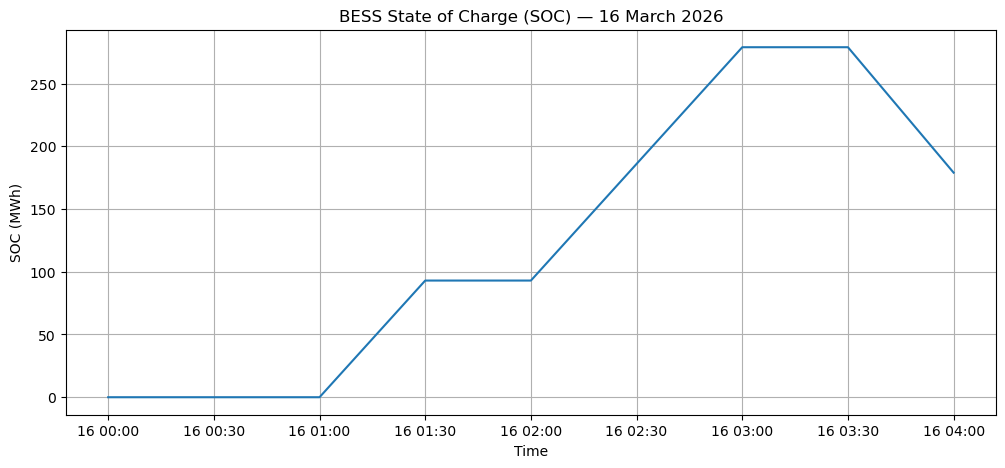

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(bess_df["SETTLEMENTDATE"], bess_df["SOC_MWH"])
plt.title("BESS State of Charge (SOC) — 16 March 2026")
plt.xlabel("Time")
plt.ylabel("SOC (MWh)")
plt.grid(True)
plt.show()

In [51]:
bess_df[bess_df["ACTION"] == "CHARGE"][
    ["SETTLEMENTDATE", "RRP"]
]

,SETTLEMENTDATE,RRP
3,2026-03-16 01:30:00,57.015702
5,2026-03-16 02:30:00,58.578307
6,2026-03-16 03:00:00,57.634825


In [52]:
bess_df.sort_values("RRP", ascending=False)[
    ["SETTLEMENTDATE", "RRP","ACTION"]
]

,SETTLEMENTDATE,RRP,ACTION
0,2026-03-16 00:00:00,68.530705,DISCHARGE
8,2026-03-16 04:00:00,65.490510,DISCHARGE
1,2026-03-16 00:30:00,63.653745,DISCHARGE
4,2026-03-16 02:00:00,60.327218,HOLD
2,2026-03-16 01:00:00,60.242388,HOLD
7,2026-03-16 03:30:00,60.076228,HOLD
5,2026-03-16 02:30:00,58.578307,CHARGE
6,2026-03-16 03:00:00,57.634825,CHARGE
3,2026-03-16 01:30:00,57.015702,CHARGE


In [53]:
bess_df

,REGIONID,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND,DATE,HOUR,MINUTE,ACTION,SOC_MWH,CHARGE_MWH,DISCHARGE_MWH
0,VIC1,2026-03-16 00:00:00,68.530705,4764,0.0,4764.0,2026-03-16,0,0,DISCHARGE,0.0,0.0,0.0
1,VIC1,2026-03-16 00:30:00,63.653745,4617,0.0,4617.0,2026-03-16,0,30,DISCHARGE,0.0,0.0,0.0
2,VIC1,2026-03-16 01:00:00,60.242388,4542,0.0,4542.0,2026-03-16,1,0,HOLD,0.0,0.0,0.0
3,VIC1,2026-03-16 01:30:00,57.015702,4500,0.0,4500.0,2026-03-16,1,30,CHARGE,93.0,100.0,0.0
4,VIC1,2026-03-16 02:00:00,60.327218,4400,0.0,4400.0,2026-03-16,2,0,HOLD,93.0,0.0,0.0
5,VIC1,2026-03-16 02:30:00,58.578307,4317,0.0,4317.0,2026-03-16,2,30,CHARGE,186.0,100.0,0.0
6,VIC1,2026-03-16 03:00:00,57.634825,4316,0.0,4316.0,2026-03-16,3,0,CHARGE,279.0,100.0,0.0
7,VIC1,2026-03-16 03:30:00,60.076228,4306,0.0,4306.0,2026-03-16,3,30,HOLD,279.0,0.0,0.0
8,VIC1,2026-03-16 04:00:00,65.490510,4337,0.0,4337.0,2026-03-16,4,0,DISCHARGE,179.0,0.0,100.0


### Identify DISCHARGE windows 

In [54]:
bess_df[bess_df["ACTION"] == "DISCHARGE"][
    ["SETTLEMENTDATE", "RRP"]
].sort_values("RRP", ascending=False).head(10)

,SETTLEMENTDATE,RRP
0,2026-03-16 00:00:00,68.530705
8,2026-03-16 04:00:00,65.490510
1,2026-03-16 00:30:00,63.653745


### identify CHARGE windows


In [55]:
bess_df[bess_df["ACTION"] == "CHARGE"][
    ["SETTLEMENTDATE", "RRP"]
].sort_values("RRP").head(10)

,SETTLEMENTDATE,RRP
3,2026-03-16 01:30:00,57.015702
6,2026-03-16 03:00:00,57.634825
5,2026-03-16 02:30:00,58.578307


In [56]:
max_price = bess_df["RRP"].max()
min_price = bess_df["RRP"].min()

print("Spread:", max_price - min_price)

Spread: 11.515003333333333


### efficiency impact

In [57]:
spread = bess_df["RRP"].max() - bess_df["RRP"].min()

efficiency = 0.93

effective_spread = spread * efficiency

print("Raw spread:", spread)
print("Effective spread after efficiency:", effective_spread)

Raw spread: 11.515003333333333
Effective spread after efficiency: 10.7089531


Key risks and uncertainties include deviations in rooftop PV generation due to weather variability, unexpected changes in demand, and forecast inaccuracies in predispatch prices. Additionally, unforeseen system events such as generator outages or network constraints could significantly alter price outcomes and reduce expected arbitrage opportunities